In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set()

In [50]:
df = pd.read_csv("Shopping_data.csv")

In [51]:
import pandas as pd

df = pd.read_csv("Shopping_data.csv")

df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [52]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

,0
age,int64
monthly_income,int64
daily_internet_hours,float64
smartphone_usage_years,int64
social_media_hours,float64
online_payment_trust_score,int64
tech_savvy_score,int64
monthly_online_orders,int64
monthly_store_visits,int64
avg_online_spend,int64


In [53]:
df.isna().sum()

,0
age,0
monthly_income,0
daily_internet_hours,0
smartphone_usage_years,0
social_media_hours,0
online_payment_trust_score,0
tech_savvy_score,0
monthly_online_orders,0
monthly_store_visits,0
avg_online_spend,0


In [54]:
df2 = df.copy()
df2.loc[0:5, 'monthly_income'] = np.nan
df2.isna().sum()

,0
age,0
monthly_income,6
daily_internet_hours,0
smartphone_usage_years,0
social_media_hours,0
online_payment_trust_score,0
tech_savvy_score,0
monthly_online_orders,0
monthly_store_visits,0
avg_online_spend,0


In [55]:
df2['monthly_income'].fillna(df2['monthly_income'].median(), inplace=True)

/tmp/ipykernel_14579/2511051415.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['monthly_income'].fillna(df2['monthly_income'].median(), inplace=True)


In [56]:
Q1 = df['monthly_income'].quantile(0.25)
Q3 = df['monthly_income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['monthly_income'] < lower) | (df['monthly_income'] > upper)]
outliers.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference


In [57]:
df_no_outliers = df[(df['monthly_income'] >= lower) & (df['monthly_income'] <= upper)]

print("Before:", df.shape)
print("After:", df_no_outliers.shape)

Before: (11789, 25)
After: (11789, 25)


In [58]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_minmax = df[['monthly_income', 'daily_internet_hours']].copy()

df_minmax[['monthly_income', 'daily_internet_hours']] = scaler.fit_transform(df_minmax)

df_minmax.head()

,monthly_income,daily_internet_hours
0,0.877107,0.500000
1,0.344806,0.654545
2,0.017235,0.490909
3,0.162415,0.490909
4,0.974581,0.454545


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['monthly_income', 'daily_internet_hours']].copy()

df_standardized[['monthly_income', 'daily_internet_hours']] = scaler.fit_transform(df_standardized)

df_standardized.head()


,monthly_income,daily_internet_hours
0,1.312530,0.247193
1,-0.523729,1.107201
2,-1.653741,0.196604
3,-1.152918,0.196604
4,1.648786,-0.005750


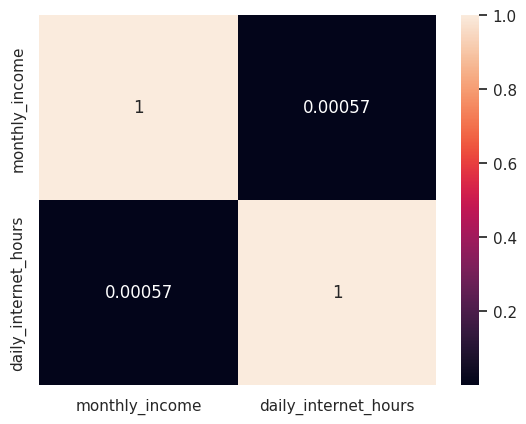

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_standardized[['monthly_income','daily_internet_hours']].corr(), annot=True)
plt.show()

In [61]:
from sklearn.decomposition import PCA

X = df_standardized[['monthly_income','daily_internet_hours']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50028741 0.49971259]


In [62]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

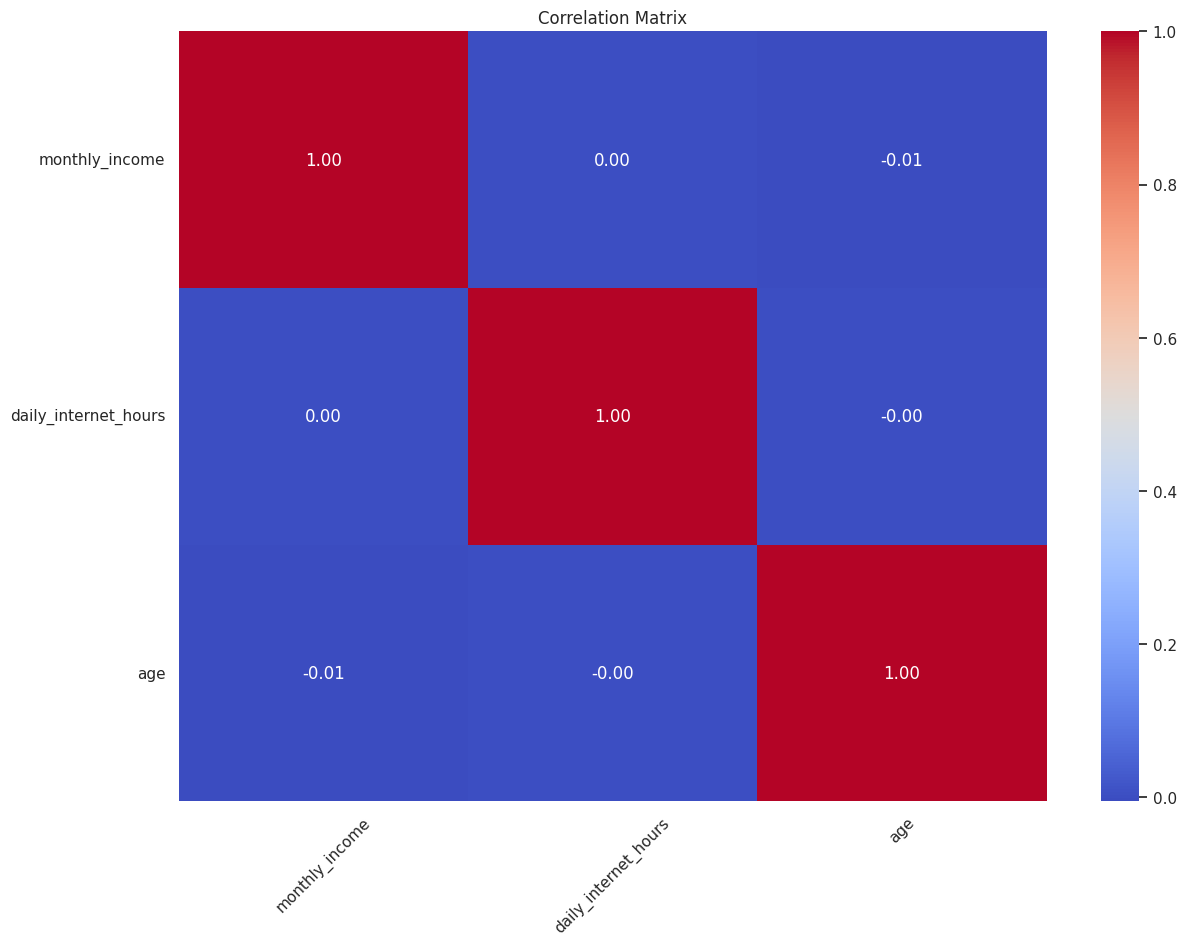

In [70]:
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Correlation Matrix")
plt.show()

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numerical_cols])

In [65]:
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])

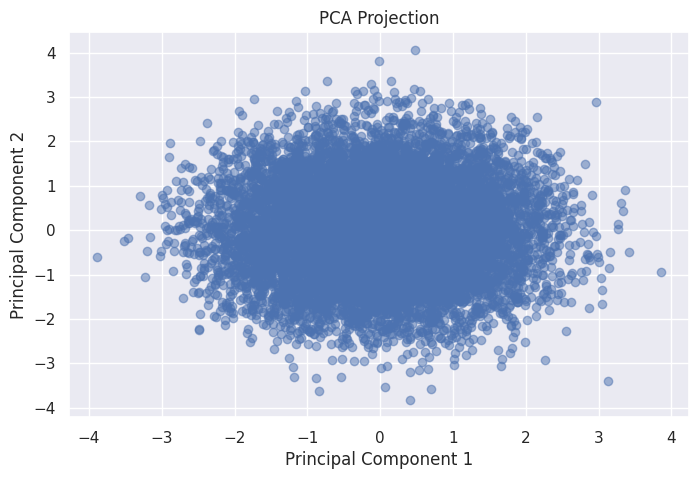

In [66]:
plt.figure(figsize=(8, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.show()

In [67]:
plt.figure(figsize=(14, 10))

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>